<a href="https://colab.research.google.com/github/ProfeAgudelo/Estadistica_inferencial_26I/blob/main/Proyecto_de_aula_Estad%C3%ADsitica_Inferencial_Ejemplo_c%C3%B3digo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t
from scipy.stats import chi2
from scipy.stats import norm

In [9]:
##Calculadora de p-valores.
def calcular_p_valor_z(z_stat):
    """
    Calcula el valor p para una prueba Z de dos colas.

    Parámetros:
    z_stat (float): El estadístico Z calculado.
    """
    # Usamos abs() para asegurar que evaluamos la cola superior,
    # sf() calcula el área a la derecha, y multiplicamos por 2 para ambas colas.
    p_valor = 2 * norm.sf(abs(z_stat))
    return print(f'El valor p es: {p_valor:.4f}')

def calcular_p_valor_t(t_stat, grados_libertad):
    """
    Calcula el valor p para una prueba t de Student de dos colas.

    Parámetros:
    t_stat (float): El estadístico t calculado.
    grados_libertad (int/float): Grados de libertad (n - 1).
    """
    p_valor = 2 * t.sf(abs(t_stat), grados_libertad)
    return print(f'El valor p es: {p_valor:.4f}')

def calcular_p_valor_chi2(chi2_stat, grados_libertad, tipo_prueba='derecha'):
    """
    Calcula el valor p para una prueba de Chi-cuadrado.
    Por defecto, asume una prueba de cola derecha (la más común para varianzas).

    Parámetros:
    chi2_stat (float): El estadístico Chi-cuadrado calculado.
    grados_libertad (int/float): Grados de libertad (n - 1).
    tipo_prueba (str): 'derecha', 'izquierda' o 'dos_colas'.
    """
    if tipo_prueba == 'derecha':
        p_valor = chi2.sf(chi2_stat, grados_libertad)
    elif tipo_prueba == 'izquierda':
        p_valor = chi2.cdf(chi2_stat, grados_libertad)
    elif tipo_prueba == 'dos_colas':
        # Calcula la probabilidad de la cola más pequeña y la multiplica por 2
        p_derecha = chi2.sf(chi2_stat, grados_libertad)
        p_izquierda = chi2.cdf(chi2_stat, grados_libertad)
        p_valor = 2 * min(p_derecha, p_izquierda)
    else:
        raise ValueError("tipo_prueba debe ser 'derecha', 'izquierda' o 'dos_colas'")

    return print(f'El valor p es: {p_valor:.4f}')

#Problema #1: Pruebas de hipótesis para la media.

##Contexto

Históricamente, los registros de la facultad indican que los estudiantes de primer semestre utilizan un promedio poblacional de 120 términos léxicos complejos por ensayo.

Este semestre, se implementó un nuevo seminario de análisis del discurso. Al finalizar, se tomó una muestra aleatoria de 40 estudiantes que cursaron este seminario y se contó la cantidad de términos complejos en sus ensayos finales.

Los datos recolectados están en la siguiente lista de Python:

In [4]:
datos_estudiantes = [
    125, 130, 118, 142, 135, 122, 128, 115, 140, 133,
    129, 121, 138, 145, 126, 119, 131, 136, 124, 127,
    141, 132, 120, 139, 134, 123, 144, 117, 137, 125,
    143, 128, 130, 116, 142, 135, 122, 138, 129, 131
]

**Misión**: Determinar si existe evidencia estadística suficiente (con un nivel de significancia $\alpha = 0.05$) para afirmar que el nuevo seminario modificó la cantidad promedio de términos complejos utilizados por los estudiantes.

##Definición de las hipotesis y el nivel de significancia

*   $H_{0}$: El seminario presento una media igual a 120 ($\mu = 120$)
*   $H_{1}$: El seminario presento una media diferente a 120 ($\mu \neq 120$)
*   El nivel de significancia es de $\alpha = 0.05$



## Cálculo de los estadísticos.

In [5]:
# 1. Calcula el tamaño de la muestra (n)
n = len(datos_estudiantes)

# 2. Calcula el promedio de la muestra (x_bar)
x_bar = np.mean(datos_estudiantes)

# 3. Calcula la desviación estándar de la muestra (s)
# Nota: usamos ddof=1 para que sea la desviación estándar muestral
s = np.std(datos_estudiantes, ddof=1)

# 4. Define el valor histórico a contrastar (mu_0)
mu_0 = 120

Con estos estadísiticos, es posible calcular el valor de t:

$$ t = \dfrac{\bar{x}-\mu_{0}}{\dfrac{s}{\sqrt{n}}}$$

Además de ello, se imprimen las variables previamente calculadas.

In [6]:
t_calculado = (x_bar - mu_0) / (s / np.sqrt(n))

print(f"Promedio de la muestra: {x_bar}")
print(f"Desviación estándar (s): {s:.2f}")
print(f"Estadístico de prueba (t): {t_calculado:.2f}")

Promedio de la muestra: 130.25
Desviación estándar (s): 8.48
Estadístico de prueba (t): 7.64


Posterior a esto, se cálcula el valor crítico para comparar y establecer el tipo de error, y el resultado de la prueba de hipótesis.

In [7]:
alfa = 0.05

# Valor crítico t para dos colas y 39 grados de libertad
t_critico = t.ppf(1 - (alfa/2), n-1)
print(f"Frontera crítica: ±{t_critico:.3f}")

Frontera crítica: ±2.023


Finalmente, se calcula el valor P usando la calculadora previamente definida. Este valor se compara en el valor de $\alpha$ para determinar si se rechaza o no $H_0$

In [10]:
calcular_p_valor_t(t_calculado, n-1)

El valor p es: 0.0000


##Respuesta del problema.
De acuerdo con los cálculos realizados, es posible afirmar que:

*   $Valor-p \leq \alpha$, por tal motivo es posible rechazar $H_o$.
*   El estadistico de prueba calculado ( $t_{calculado}$) es mucho mayor que el valor de t crítico ($t_{\frac{\alpha}{2},n-1}$).Es posible rechazar $H_o$.

De este modo, se descarta $H_{0}$ y se toma como referencia $H_{1}$ con un 95% de confianza. Ahora bien, teniendo en cuenta que la estadística no es perfecta, tenemos un margen del 5% de tener un error del Tipo I.

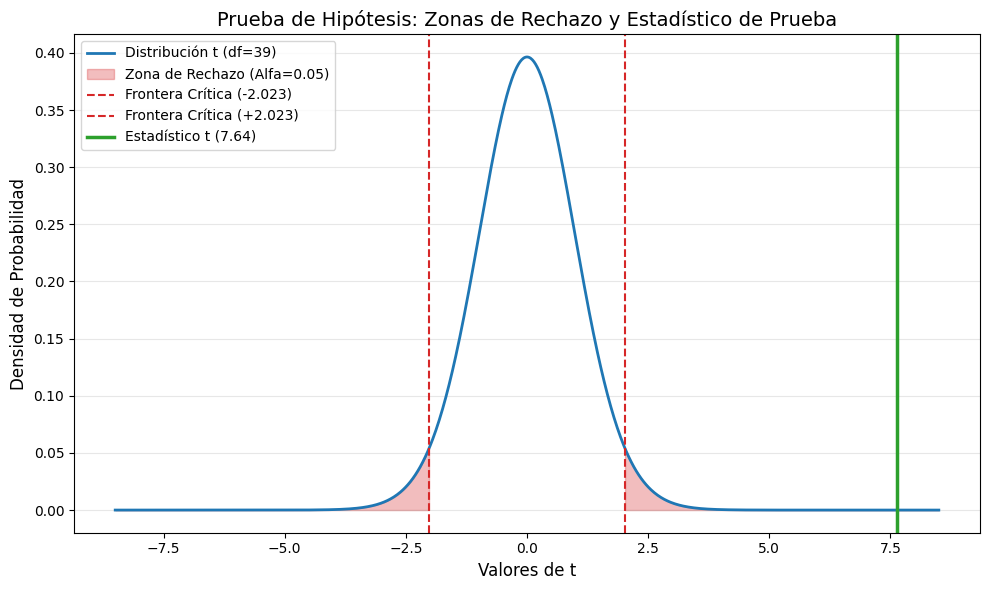

In [11]:
# Crear el rango de valores para el eje X (hacemos un rango amplio de -8.5 a 8.5
# porque tu estadístico calculado de 7.64 está muy lejos del centro)
x = np.linspace(-8.5, 8.5, 1000)

# Calcular los valores de la distribución t para esos puntos X
y = t.pdf(x, n-1)

plt.figure(figsize=(10, 6))

# 1. Dibujar la campana principal
plt.plot(x, y, label=f'Distribución t (df={n-1})', color='#1f77b4', linewidth=2)

# 2. Sombrear la zona de rechazo izquierda
x_izq = np.linspace(-8.5, -t_critico, 100)
plt.fill_between(x_izq, t.pdf(x_izq, n-1), color='#d62728', alpha=0.3, label='Zona de Rechazo (Alfa=0.05)')

# 3. Sombrear la zona de rechazo derecha
x_der = np.linspace(t_critico, 8.5, 100)
plt.fill_between(x_der, t.pdf(x_der, n-1), color='#d62728', alpha=0.3)

# 4. Marcar las banderas (Valores críticos)
plt.axvline(-t_critico, color='#d62728', linestyle='--', linewidth=1.5, label=f'Frontera Crítica (-{t_critico:.3f})')
plt.axvline(t_critico, color='#d62728', linestyle='--', linewidth=1.5, label=f'Frontera Crítica (+{t_critico:.3f})')

# 5. Marcar tu estadístico calculado (Tu ubicación)
plt.axvline(t_calculado, color='#2ca02c', linewidth=2.5, label=f'Estadístico t ({t_calculado:.2f})')

# Configuraciones de estética del gráfico
plt.title('Prueba de Hipótesis: Zonas de Rechazo y Estadístico de Prueba', fontsize=14)
plt.xlabel('Valores de t', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()